In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pandas.plotting import autocorrelation_plot
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from prophet import Prophet
from tensorflow import keras
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras import Sequential

In [ ]:
# Download the data
ticker = "BTC-USD"
start_date = "2018-01-01"
end_date = "2025-05-31"
df = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


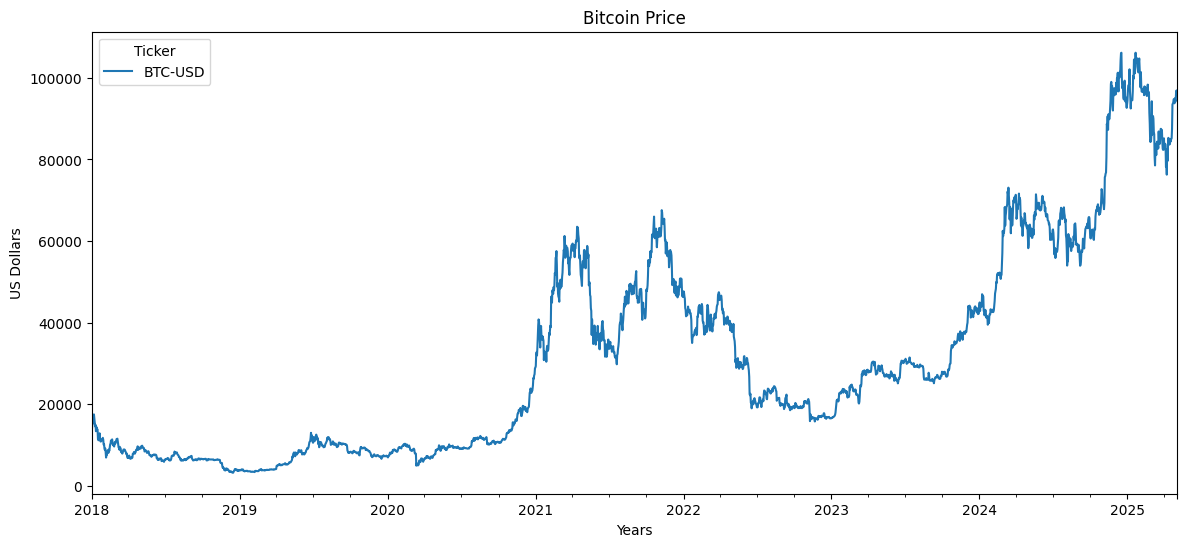

In [ ]:
# Plot Bitcoin Price
df.Close.plot(title="Bitcoin Price", figsize=(14,6))
plt.xlabel('Years')
plt.ylabel('US Dollars')
plt.show()

In [ ]:
# Create lag features
df['Lag1'] = df['Close'].shift(1)
df['Lag7'] = df['Close'].shift(7)
df['Lag30'] = df['Close'].shift(30)

# Create rolling statistics
df['Rolling_Mean_7'] = df['Close'].rolling(window=7).mean()
df['Rolling_Mean_30'] = df['Close'].rolling(window=30).mean()
df['Rolling_Std_7'] = df['Close'].rolling(window=7).std()

# Drop NaN values generated by shifts and rolling
df.dropna(inplace=True)

In [ ]:
# Extract date-related features
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Dayofweek'] = df.index.dayofweek  # Monday=0, Sunday=6
df['Is_weekend'] = (df.index.dayofweek >= 5).astype(int)  # 1 if weekend, 0 otherwise

# Now, you can select your features:
X = df[['Year', 'Month', 'Day', 'Dayofweek', 'Is_weekend', 'Lag1', 'Lag7', 'Lag30', 'Rolling_Mean_7', 'Rolling_Mean_30', 'Rolling_Std_7']]
y = df['Close']

In [ ]:
# Split data into training and testing
split_date = '2023-01-01'
train_data = df[:split_date]
test_data = df[split_date:]

In [ ]:
X_train, X_test = train_data[X.columns], test_data[X.columns]
y_train, y_test = train_data['Close'], test_data['Close']

In [ ]:
# 1. XGBoost - Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'n_estimators': [50, 100, 150],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

In [ ]:
# Set up RandomizedSearchCV for better hyperparameter optimization
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)
best_xgb_model = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
# Train the optimized model
best_xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Predictions and Evaluation
xgb_pred = best_xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb = r2_score(y_test, xgb_pred)

print(f"XGBoost - MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.4f}")

XGBoost - MAE: 8638.32, RMSE: 15443.24, R²: 0.6343


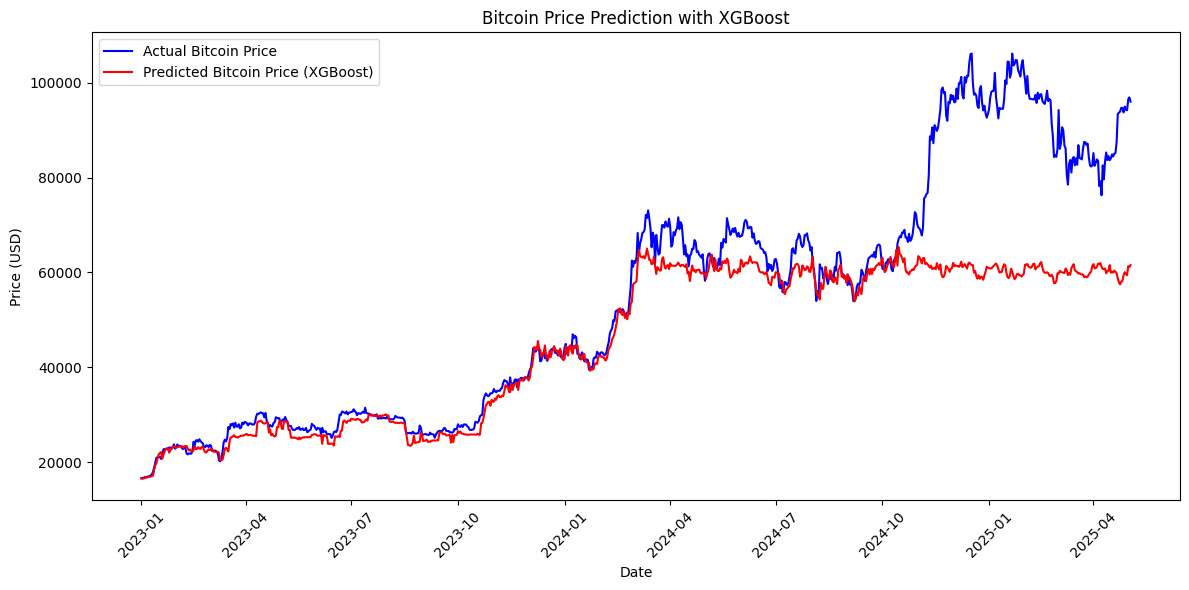

In [ ]:
# Plot XGBoost Predictions vs Actual
plt.figure(figsize=(12,6))
plt.plot(test_data.index, y_test, label='Actual Bitcoin Price', color='blue')
plt.plot(test_data.index, xgb_pred, label='Predicted Bitcoin Price (XGBoost)', color='red')
plt.title('Bitcoin Price Prediction with XGBoost')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model performance
xgb_mae = mean_absolute_error(y_test, xgb_pred) # Changed y_pred to xgb_pred
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred)) # Changed y_pred to xgb_pred
xgb_r2 = r2_score(y_test, xgb_pred) # Changed y_pred to xgb_pred

# Print XGBoost metrics
print(f"XGBoost Metrics: MAE={xgb_mae:.2f}, RMSE={xgb_rmse:.2f}, R²={xgb_r2:.4f}")

XGBoost Metrics: MAE=8638.32, RMSE=15443.24, R²=0.6343


In [ ]:
# Prophet Model
df2 = df.copy()
df2.reset_index(inplace=True)
df2 = df2[['Date', 'Close']]
df2.columns = ['ds', 'y']

In [ ]:
model_prophet = Prophet()
model_prophet.fit(df2)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefkz1aj4/nnpwtyr4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefkz1aj4/daal3j9_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=70298', 'data', 'file=/tmp/tmpefkz1aj4/nnpwtyr4.json', 'init=/tmp/tmpefkz1aj4/daal3j9_.json', 'output', 'file=/tmp/tmpefkz1aj4/prophet_modelpoci201j/prophet_model-20250503121952.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:19:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:19:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# Make future dataframe for 7 days
future = model_prophet.make_future_dataframe(periods=7, freq='D')
forecast_prophet = model_prophet.predict(future)

In [ ]:
# Evaluate Prophet
prophet_actual = df2['y'].iloc[-7:].values
prophet_predicted = forecast_prophet['yhat'].tail(7).values
mae_prophet = mean_absolute_error(prophet_actual, prophet_predicted)
rmse_prophet = np.sqrt(mean_squared_error(prophet_actual, prophet_predicted))
r2_prophet = r2_score(prophet_actual, prophet_predicted)

print(f"Prophet - MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}, R²: {r2_prophet:.4f}")

Prophet - MAE: 4931.57, RMSE: 5063.31, R²: -18.4768


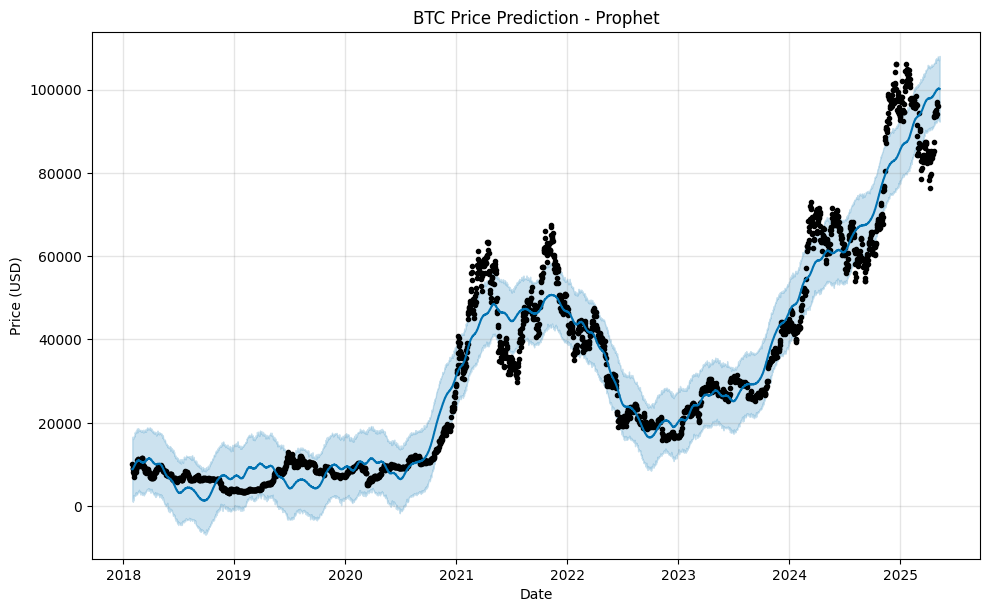

In [ ]:
# Plot Prophet Forecast
model_prophet.plot(forecast_prophet)
plt.title('BTC Price Prediction - Prophet')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

In [ ]:
# Normalize Close Price for KMeans
scaler = MinMaxScaler()
close_prices_scaled = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [ ]:
# Optimal Cluster Number (using Elbow Method)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(close_prices_scaled)
    inertia.append(kmeans.inertia_)

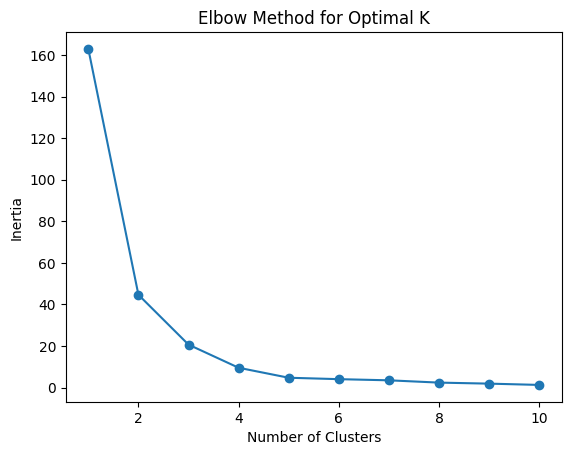

In [ ]:
# Plot inertia to determine optimal clusters
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# Based on the Elbow method, we choose n_clusters=5 (or your optimal value)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(close_prices_scaled)

df['Cluster'] = kmeans.labels_

In [ ]:
# Predicting Next 7 Days from Recent Cluster
recent_cluster = df['Cluster'].iloc[-1]
recent_prices = df[df['Cluster'] == recent_cluster]['Close']

In [ ]:
# Fit linear regression to predict the trend from the cluster
recent_prices = recent_prices[-30:]  # Using last 30 prices
x = np.arange(len(recent_prices))
y = recent_prices.values
coeffs = np.polyfit(x, y, deg=1)

In [ ]:
# Predict next 7 days
x_future = np.arange(len(recent_prices), len(recent_prices) + 7)
future_prices = np.polyval(coeffs, x_future)

print("KMeans Next 7 Days Prediction:", future_prices)

KMeans Next 7 Days Prediction: [ 97569.48462644  98189.18445785  98808.88428926  99428.58412067
 100048.28395208 100667.98378349 101287.6836149 ]


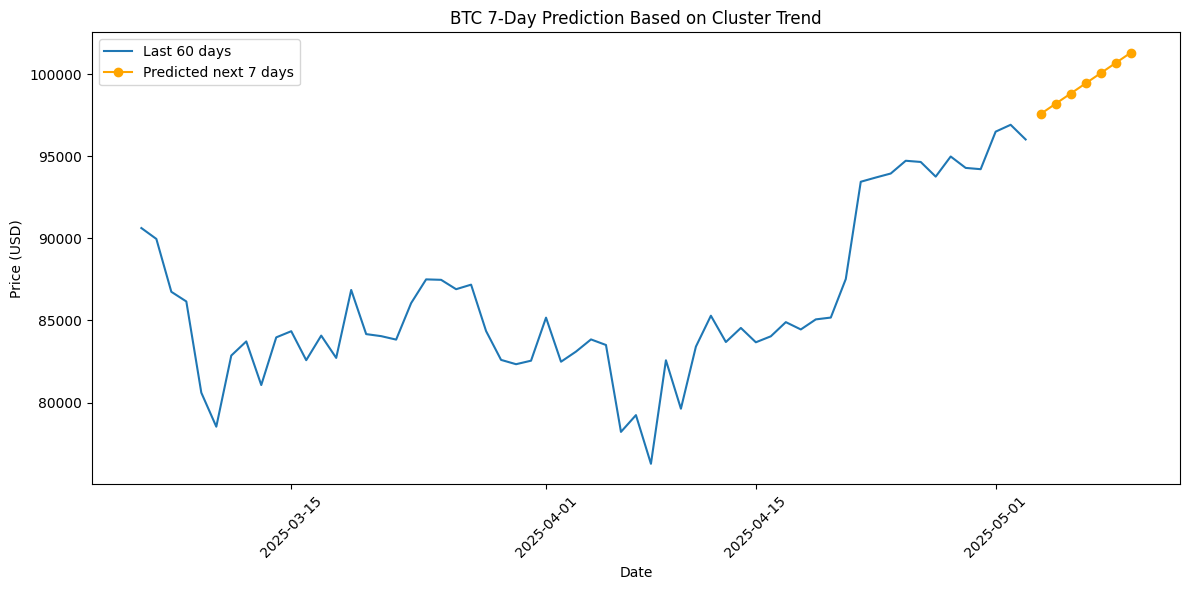

In [ ]:
# Plot KMeans Prediction
plt.figure(figsize=(12, 6))
plt.plot(df.index[-60:], df['Close'].iloc[-60:], label="Last 60 days")
plt.plot([df.index[-1] + pd.Timedelta(days=i) for i in range(1, 8)], future_prices, marker='o', label="Predicted next 7 days", color='orange')
plt.title('BTC 7-Day Prediction Based on Cluster Trend')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate KMeans performance
kmeans_actual = df['Close'].iloc[-7:].values  # Actual Bitcoin prices for the last 7 days
kmeans_predicted = future_prices  # Predicted values from KMeans linear trend

# Calculate MAE, RMSE, and R²
mae_kmeans = mean_absolute_error(kmeans_actual, kmeans_predicted)
rmse_kmeans = np.sqrt(mean_squared_error(kmeans_actual, kmeans_predicted))
r2_kmeans = r2_score(kmeans_actual, kmeans_predicted)

# Print metrics
print(f"KMeans - MAE: {mae_kmeans:.2f}, RMSE: {rmse_kmeans:.2f}, R²: {r2_kmeans:.4f}")

KMeans - MAE: 4193.56, RMSE: 4261.68, R²: -12.7978


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [ ]:
# Prepare data for LSTM
X = []
y = []
sequence_length = 60
for i in range(sequence_length, len(scaled_data) - 7):
    X.append(scaled_data[i - sequence_length:i, 0])
    y.append(scaled_data[i:i + 7, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
# Split into training and test sets
split_index = int(0.9 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [ ]:
# Build the LSTM Model
model_lstm = Sequential()
model_lstm.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(100))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(7))  # Predict 7 future days

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Setup EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model_lstm.fit(
    X_train, y_train,
    epochs=100,                 # You can go high, it will stop early if needed
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - loss: 0.0189 - val_loss: 0.0080
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - loss: 0.0023 - val_loss: 0.0124
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0020 - val_loss: 0.0046
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0016 - val_loss: 0.0130
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0016 - val_loss: 0.0023
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0015 - val_loss: 0.0049
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0013 - val_loss: 0.0082
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0013 - val_loss: 0.0033
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 0.0013 - val_loss: 0.0039
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predict next 7 days using LSTM
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)
next_7_days_scaled = model_lstm.predict(last_60_days)
next_7_days = scaler.inverse_transform(next_7_days_scaled)

print(f"LSTM Next 7 Days Prediction: {next_7_days[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
LSTM Next 7 Days Prediction: [95748.08  95945.58  96772.734 95900.305 95719.086 94505.664 93201.76 ]


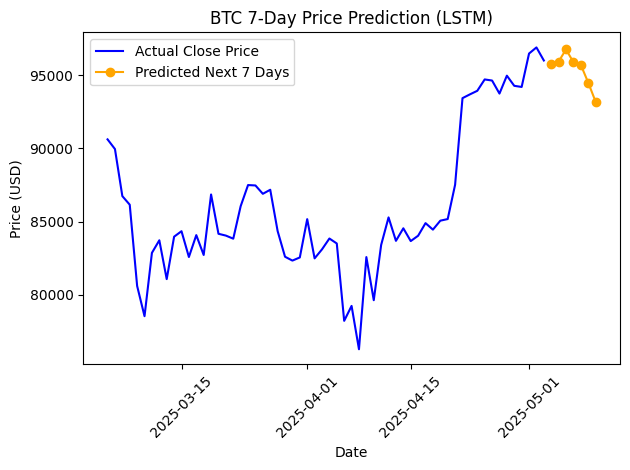

In [ ]:
# Plot LSTM Prediction
next_dates = [df.index[-1] + pd.Timedelta(days=i) for i in range(1, 8)]
plt.plot(df.index[-60:], df['Close'].iloc[-60:], label="Actual Close Price", color='blue')
plt.plot(next_dates, next_7_days[0], label="Predicted Next 7 Days", color='orange', marker='o')
plt.title('BTC 7-Day Price Prediction (LSTM)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Accuracy Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)
    return mae, mse, rmse, r2

# Prophet
prophet_actual = df2['y'].iloc[-7:].values
prophet_predicted = forecast_prophet['yhat'].tail(7).values
prophet_mae, prophet_mse, prophet_rmse, prophet_r2 = evaluate_model(prophet_actual, prophet_predicted)

# KMeans
kmeans_actual = df['Close'].iloc[-7:].values
kmeans_predicted = future_prices
kmeans_mae, kmeans_mse, kmeans_rmse, kmeans_r2 = evaluate_model(kmeans_actual, kmeans_predicted)

# LSTM
lstm_actual = df['Close'].iloc[-7:].values
lstm_predicted = next_7_days[0]
lstm_mae, lstm_mse, lstm_rmse, lstm_r2 = evaluate_model(lstm_actual, lstm_predicted)

# Print metrics
print(f"Prophet Metrics: MAE={prophet_mae:.2f}, RMSE={prophet_rmse:.2f}, R²={prophet_r2:.4f}")
print(f"KMeans Metrics: MAE={kmeans_mae:.2f}, RMSE={kmeans_rmse:.2f}, R²={kmeans_r2:.4f}")
print(f"LSTM Metrics: MAE={lstm_mae:.2f}, RMSE={lstm_rmse:.2f}, R²={lstm_r2:.4f}")

Prophet Metrics: MAE=4931.57, RMSE=5063.31, R²=-18.4768
KMeans Metrics: MAE=4193.56, RMSE=4261.68, R²=-12.7978
LSTM Metrics: MAE=1876.28, RMSE=2009.59, R²=-2.0681


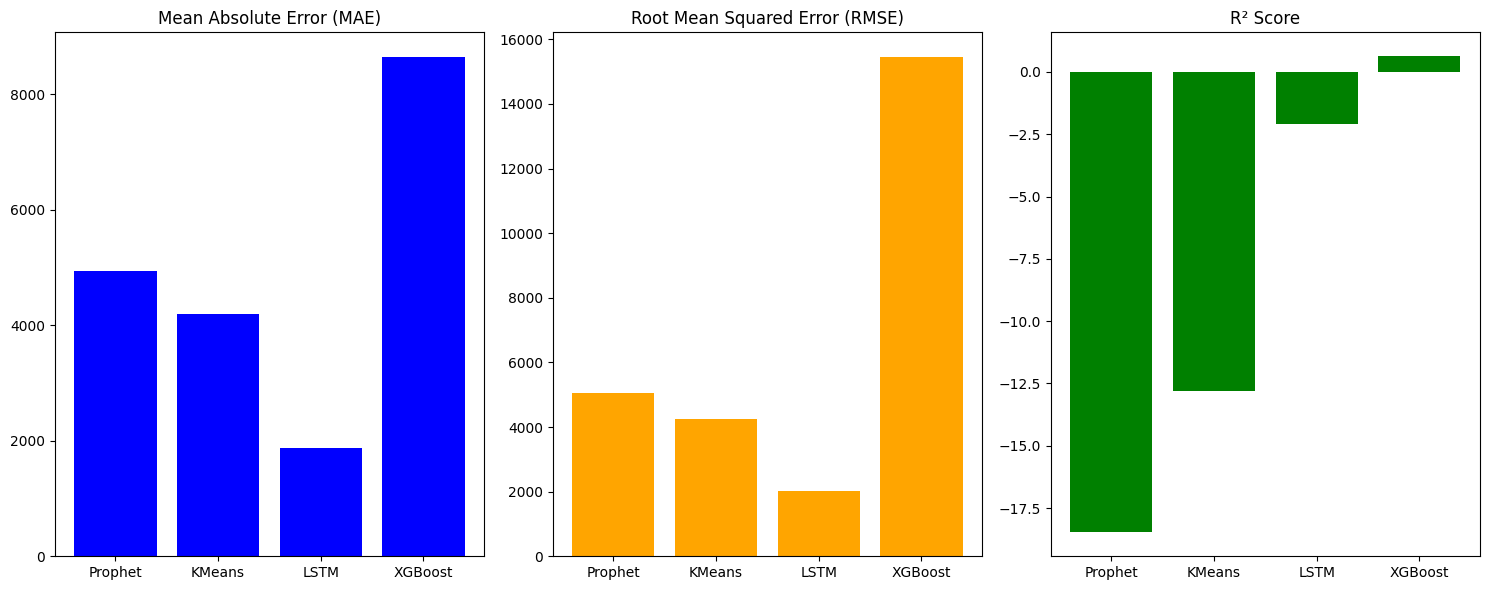

In [ ]:
# Bar Plot for Comparison
# Add XGBoost to the comparison lists
models = ['Prophet', 'KMeans', 'LSTM', 'XGBoost']
mae_values = [prophet_mae, kmeans_mae, lstm_mae, xgb_mae]
rmse_values = [prophet_rmse, kmeans_rmse, lstm_rmse, xgb_rmse]
r2_values = [prophet_r2, kmeans_r2, lstm_r2, xgb_r2]

# Bar Plot for Comparison (Including XGBoost)
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# MAE Bar Plot
axs[0].bar(models, mae_values, color='blue')
axs[0].set_title('Mean Absolute Error (MAE)')

# RMSE Bar Plot
axs[1].bar(models, rmse_values, color='orange')
axs[1].set_title('Root Mean Squared Error (RMSE)')

# R² Bar Plot
axs[2].bar(models, r2_values, color='green')
axs[2].set_title('R² Score')

plt.tight_layout()
plt.show()